In [1]:
from collections import Counter

import torch

import altair as alt
from scipy.stats import pearsonr

import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency
import tqdm

from natsort import natsorted
import logomaker

from netam import framework
from dnsmex import dxsm_data, dnsm_zoo
from dnsmex.dnsm_oe import write_sites_oe
from dnsmex.local import localify


from netam.common import heavy_chain_shim
from netam.framework import load_crepe, load_pcp_df
from netam.sequences import translate_sequence, AA_STR_SORTED

from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.dxsm_data import pcp_df_of_nickname

figures_dir = localify("FIGURES_DIR")

## Prep data - Rodriguez dataset

In [2]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


In [3]:
dataset_name = "v1rodriguez"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try:
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]


    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    for column_name in ['selection_factor', 'neutral_prob', 'prob']:
        site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)



    def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
        site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
        site_counts = site_sub_probs_df["site"].value_counts()
        cutoff = site_counts.quantile(quantile_cutoff)
        sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
        site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
        return site_sub_probs_df

    def sort_df_by_site(df):
        sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
        return df.iloc[sorted_index]

    def build_persite_df(site_sub_probs_df):
        persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
            mean_prob=('prob', 'mean'),
            mean_neutral_prob=('neutral_prob', 'mean'),
            mean_selection_factor=('selection_factor', 'mean'),
            mut_freq=('mutation', 'mean')
        ).reset_index()

        persite_df = sort_df_by_site(persite_df)

        return persite_df



In [4]:
# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


<Axes: xlabel='site', ylabel='Count'>

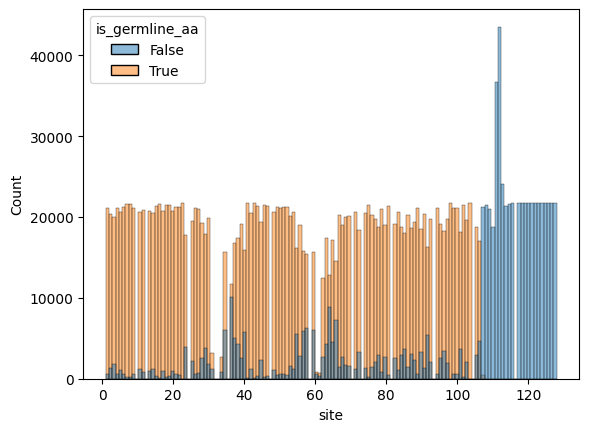

In [5]:
## add germline information
germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
codon_similarity = pd.read_csv(localify(f"DATA_DIR/germline_codon_similarity.csv"))
aa_similarity = pd.read_csv(localify(f"DATA_DIR/germline_aa_similarity.csv"))
aa_similarity.set_index('v_gene', inplace=True)
codon_similarity.set_index('v_gene', inplace=True)





germline_codons_df['site'] = germline_codons_df['site'].astype(float)

site_sub_probs_df_germline = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')

site_sub_probs_df_germline['is_germline_aa'] = site_sub_probs_df_germline.parent_aa == site_sub_probs_df_germline.germline_amino_acid
site_sub_probs_df_germline['is_germline_codon'] = site_sub_probs_df_germline.parent_codon == site_sub_probs_df_germline.germline_codon
sns.histplot(site_sub_probs_df_germline, x='site', hue='is_germline_aa')

In [6]:
site_sub_probs_df_germline

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,j_gene,v_family,j_family,sample_id,family,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon
0,0.102066,0.132334,0.013507,False,0,1.0,False,CAG,Q,CAG,...,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True
1,0.030019,0.132334,0.003972,False,1,1.0,False,CAG,Q,CAG,...,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True
2,0.011072,0.229902,0.002546,False,2,1.0,False,CAG,Q,CAG,...,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-24,474,-1.470103,CAG,Q,True,True
3,0.054606,0.262477,0.014333,False,3,1.0,False,CAG,Q,CAG,...,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True
4,0.010781,0.262477,0.002830,False,4,1.0,False,CAG,Q,CAG,...,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHJ1*01,IGHV1,IGHJ1,sample-igg-W-109,62,0.115481,NaN,NaN,False,False
2646367,0.001785,1.077277,0.001923,False,21748,128.0,False,TCA,S,TCA,...,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False
2646368,0.001744,1.077277,0.001879,False,21749,128.0,False,TCA,S,TCA,...,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False
2646369,0.001797,1.249783,0.002246,False,21750,128.0,False,TCA,S,TCA,...,IGHJ4*02,IGHV1,IGHJ4,sample-igg-W-117,10,0.222970,NaN,NaN,False,False


In [7]:
def is_parent_child_one_mutation_away(parent_codon, child_codon):
    """
    Check if two codons are one mutation away from each other.
    """
    if parent_codon == child_codon:
        return False
    # Check if they differ by exactly one nucleotide mutation
    mutations = sum(1 for p, c in zip(parent_codon, child_codon) if p != c)
    return mutations == 1

site_sub_probs_df_germline['is_one_mutation_away'] = site_sub_probs_df_germline.apply(
    lambda row: is_parent_child_one_mutation_away(row['parent_codon'], row['child_codon']),
    axis=1
)

In [8]:
site_sub_probs_df_germline.groupby(['mutation', 'is_one_mutation_away']).size().reset_index()


,mutation,is_one_mutation_away,0
0,False,False,2450908
1,False,True,72290
2,True,False,22033
3,True,True,101140


In [55]:
def calculate_association_between_sites(site_sub_probs_df, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities.

    Simplest function - doesn't matter what the parent or child is, only aggregating over an occurence of a mutaiton at each site.
    """
    cfs_with_site1_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site1) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_with_site2_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site2) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    
    cfs_count = len(site_sub_probs_df_germline[['family', 'sample_id']].drop_duplicates())

    cfs_with_both_mutations = len(pd.merge(cfs_with_site1_mutation, cfs_with_site2_mutation, on=['family', 'sample_id'], how='inner'))
    cfs_with_site1_mutation_only = len(cfs_with_site1_mutation) - cfs_with_both_mutations
    cfs_with_site2_mutation_only = len(cfs_with_site2_mutation) - cfs_with_both_mutations
    cfs_with_neither_mutation = cfs_count - (cfs_with_both_mutations + cfs_with_site1_mutation_only + cfs_with_site2_mutation_only)
    
    contingency_table = np.array([
        [cfs_with_both_mutations, cfs_with_site1_mutation_only],
        [cfs_with_site2_mutation_only, cfs_with_neither_mutation]
    ])  
    # calculate chi-squared statistic with package
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)

    return contingency_table, chi2, p_value

    


In [56]:
calculate_association_between_sites(site_sub_probs_df_germline, 30,50)

(array([[  65,  744],
        [ 264, 6688]]),
 np.float64(31.014164852694417),
 np.float64(2.5615218239724437e-08))

In [67]:
results = []
for i in tqdm.tqdm(range(30, 50)):
    for j in range(30, 50):
        if i != j:
            try:
                contingency_table, chi2, p_value = calculate_association_between_sites(site_sub_probs_df_germline, i, j)
                results.append({
                    'site1': i,
                    'site2': j,
                    'contingency_table': contingency_table,
                    'chi2': chi2,
                    'p_value': p_value
                })
            except:
                pass
results_df = pd.DataFrame(results)



100%|██████████| 20/20 [00:50<00:00,  2.50s/it]


In [68]:
# apply FDR correction to p-values
from statsmodels.stats.multitest import multipletests
results_df['fdr_corrected_p_value'] = multipletests(results_df['p_value'], method='fdr_bh')[1]


<Axes: >

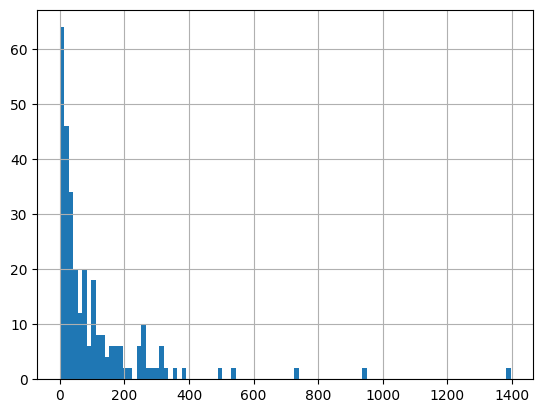

In [69]:
results_df.chi2.hist(bins=100)

<Axes: >

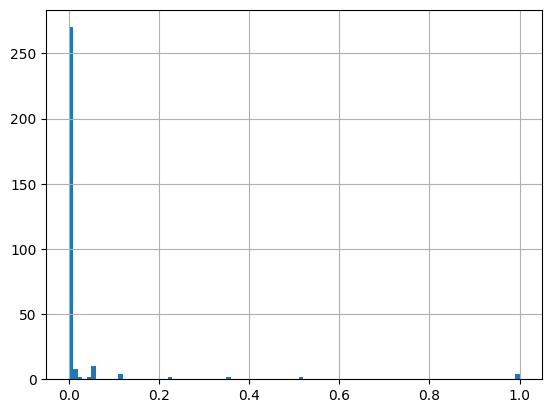

In [70]:
results_df.p_value.hist(bins=100)

<Axes: >

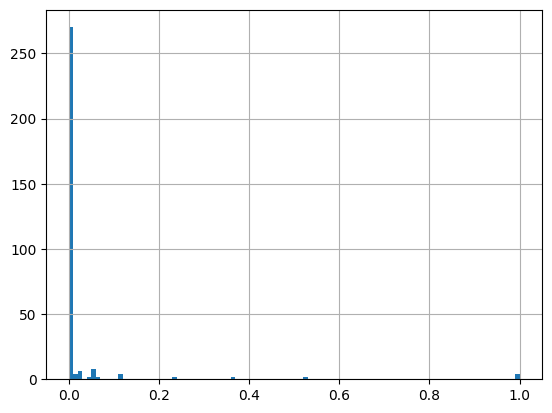

In [71]:
results_df['fdr_corrected_p_value'].hist(bins=100)  

Text(0.5, 1.0, 'Chi2 vs P-value for Site Associations')

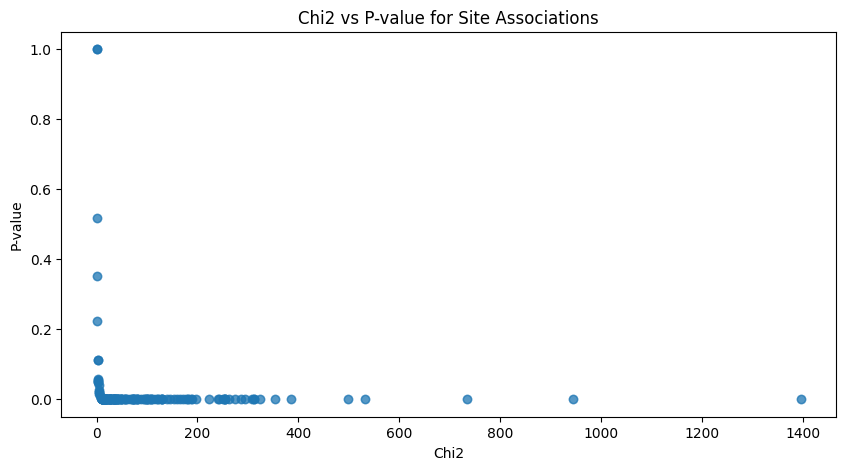

In [74]:
# plot the dostribution of chi2 and p-values pairs

plt.figure(figsize=(10, 5))
plt.scatter(results_df.chi2, results_df.p_value, alpha=0.5)
plt.xlabel('Chi2')
plt.ylabel('P-value')
plt.title('Chi2 vs P-value for Site Associations')

In [75]:
results_df.sort_values(by='chi2', ascending=True, inplace=True)

In [76]:
results_df

,site1,site2,contingency_table,chi2,p_value,fdr_corrected_p_value
27,31,43,"[[1, 440], [25, 7295]]",0.000000,1.000000e+00,1.000000e+00
189,43,34,"[[1, 25], [294, 7441]]",0.000000,1.000000e+00,1.000000e+00
188,43,31,"[[1, 25], [440, 7295]]",0.000000,1.000000e+00,1.000000e+00
44,34,43,"[[1, 294], [25, 7441]]",0.000000,1.000000e+00,1.000000e+00
47,34,46,"[[8, 287], [149, 7317]]",0.417457,5.182084e-01,5.250721e-01
...,...,...,...,...,...,...
72,36,37,"[[876, 1505], [578, 4802]]",733.841822,1.308646e-161,6.674094e-160
71,36,35,"[[1238, 1143], [962, 4418]]",944.007315,2.663236e-207,2.037376e-205
54,35,36,"[[1238, 962], [1143, 4418]]",944.007315,2.663236e-207,2.037376e-205
18,31,34,"[[163, 278], [132, 7188]]",1396.481088,1.222072e-305,1.869770e-303


In [77]:
def calculate_association_between_sites(site_sub_probs_df, site1, site2):
    """
    Calculate the association between two sites based on their mutation probabilities.

    Simplest function - doesn't matter what the parent or child is, only aggregating over an occurence of a mutaiton at each site.
    """
    cfs_with_site1_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site1) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    cfs_with_site2_mutation = site_sub_probs_df[(site_sub_probs_df['site'] == site2) & (site_sub_probs_df_germline.mutation == True)][['family', 'sample_id']].drop_duplicates()
    
    cfs_count = len(site_sub_probs_df_germline[['family', 'sample_id']].drop_duplicates())

    cfs_with_both_mutations = len(pd.merge(cfs_with_site1_mutation, cfs_with_site2_mutation, on=['family', 'sample_id'], how='inner'))
    cfs_with_site1_mutation_only = len(cfs_with_site1_mutation) - cfs_with_both_mutations
    cfs_with_site2_mutation_only = len(cfs_with_site2_mutation) - cfs_with_both_mutations
    cfs_with_neither_mutation = cfs_count - (cfs_with_both_mutations + cfs_with_site1_mutation_only + cfs_with_site2_mutation_only)
    
    contingency_table = np.array([
        [cfs_with_both_mutations, cfs_with_site1_mutation_only],
        [cfs_with_site2_mutation_only, cfs_with_neither_mutation]
    ])  
    
    # calculate chi-squared statistic with package
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    # Determine association type
    observed_both = cfs_with_both_mutations
    observed_neither = cfs_with_neither_mutation
    observed_site1_only = cfs_with_site1_mutation_only
    observed_site2_only = cfs_with_site2_mutation_only
    
    # Calculate odds ratio to determine association direction
    if observed_site1_only * observed_site2_only == 0:
        # Avoid division by zero
        odds_ratio = float('inf') if observed_both * observed_neither > 0 else 0
    else:
        odds_ratio = (observed_both * observed_neither) / (observed_site1_only * observed_site2_only)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = "positive"  # Co-occurrence
    elif odds_ratio < 1:
        association_type = "negative"  # Mutual exclusion
    else:
        association_type = "independent"
    
    return contingency_table, chi2, p_value, odds_ratio, association_type

In [79]:
table, chi2, p_val, odds_ratio, assoc_type = calculate_association_between_sites(site_sub_probs_df_germline, 30, 50)
print(f"Chi2: {chi2:.3f}, p: {p_val:.3e}, OR: {odds_ratio:.3f}, Type: {assoc_type}")

Chi2: 31.014, p: 2.562e-08, OR: 2.213, Type: positive


In [90]:
results = []
sites = site_sub_probs_df_germline['site'].unique()
for i in tqdm.tqdm(sites):
    for j in sites:
        if i > j:
            try:
                contingency_table, chi2, p_value, odds_ratio, association_type = calculate_association_between_sites(site_sub_probs_df_germline, i, j)
                results.append({
                    'site1': i,
                    'site2': j,
                    'contingency_table': contingency_table,
                    'chi2': chi2,
                    'p_value': p_value,
                    'odds_ratio': odds_ratio,
                    'association_type': association_type

                })
            except:
                pass
results_df = pd.DataFrame(results)



  0%|          | 0/144 [00:00<?, ?it/s]

100%|██████████| 144/144 [22:37<00:00,  9.43s/it]


results_df.to_csv(f"{test_output_prefix}-counts_association_results.csv", index=False)

In [94]:
results_df.association_type.value_counts()

association_type
positive    8529
negative     924
Name: count, dtype: int64

In [82]:
results_df.sort_values(by='association_type')

,site1,site2,contingency_table,chi2,p_value,odds_ratio,association_type
40,34,39,"[[5, 290], [792, 6674]]",23.508986,1.243317e-06,0.145289,negative
23,31,39,"[[7, 434], [790, 6530]]",37.255014,1.036482e-09,0.133320,negative
188,43,31,"[[1, 25], [440, 7295]]",0.000000,1.000000e+00,0.663182,negative
120,39,31,"[[7, 790], [434, 6530]]",37.255014,1.036482e-09,0.133320,negative
121,39,34,"[[5, 792], [290, 6674]]",23.508986,1.243317e-06,0.145289,negative
...,...,...,...,...,...,...,...
100,37,48,"[[298, 1156], [437, 5870]]",252.071455,9.180179e-57,3.462702,positive
99,37,47,"[[90, 1364], [149, 6158]]",56.717516,5.031339e-14,2.726978,positive
98,37,46,"[[56, 1398], [101, 6206]]",29.057378,7.026598e-08,2.461338,positive
96,37,44,"[[91, 1363], [164, 6143]]",48.619676,3.107360e-12,2.500819,positive


In [ ]:
results_df['log_odds_ratio'] = np.log(results_df['odds_ratio'])


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


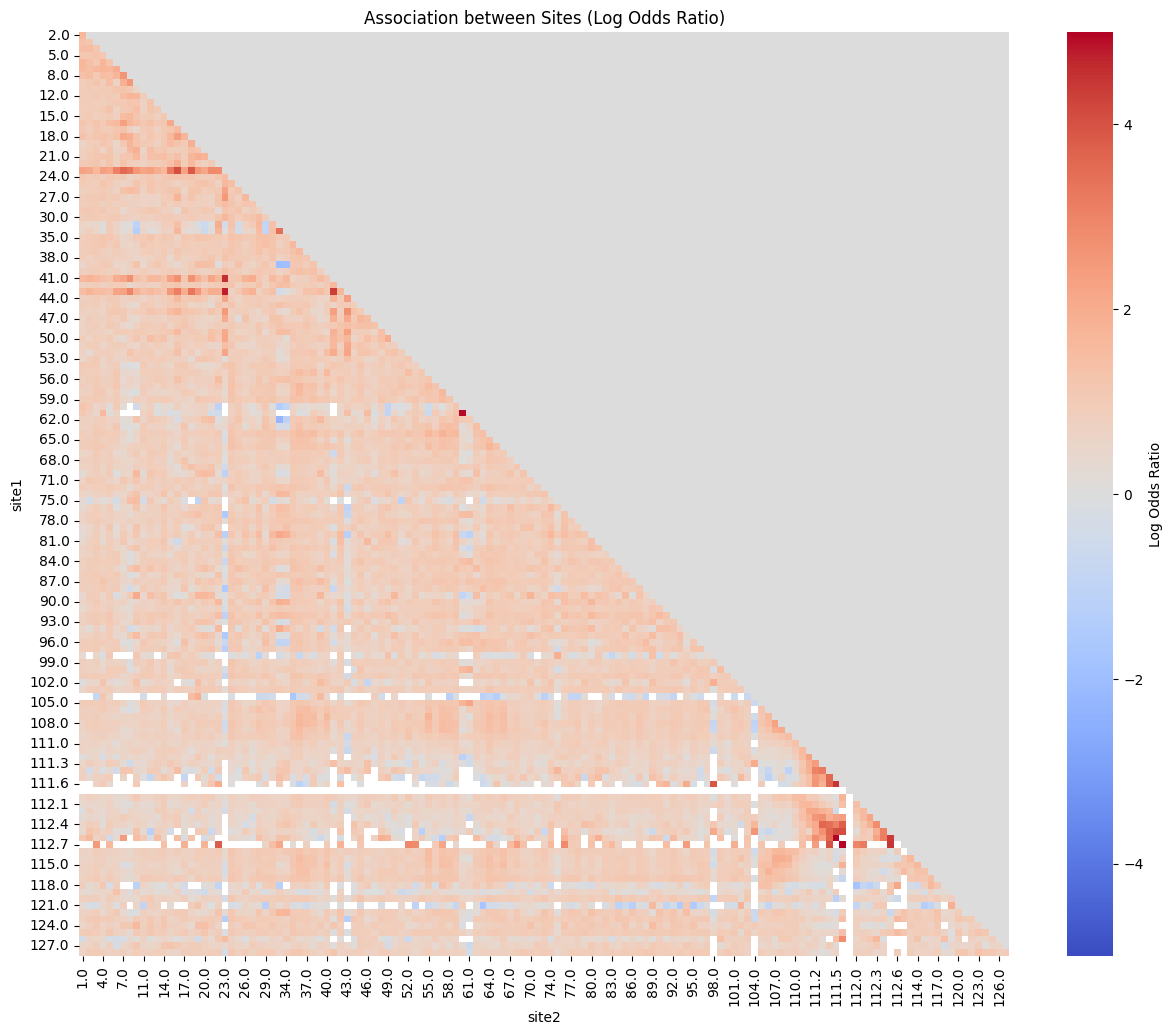

In [ ]:
# plot a heatmap for the association between sites using the log_odds_ratio
heatmap_data = results_df.pivot_table(index='site1', columns='site2', values='log_odds_ratio', fill_value=0)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.index))
heatmap_data = heatmap_data.astype(float)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(heatmap_data, cmap='coolwarm',cbar_kws={'label': 'Log Odds Ratio'}, vmin=-5, vmax=5)
plt.title('Association between Sites (Log Odds Ratio)')
plt.show()

In [ ]:
## need to first filter only for pcps where both sites imgt are present
## also - maybe filter for a subset of pcps. maybe a v family? maybe a v gene?
## need to flip the 112,1, 112.4 order etc

## also, maybe remove the germline filter??

In [32]:
def calculate_association_between_sites(site_sub_probs_df_germline, site1, site2, v_family=None):
    """
    Calculate the association between two sites based on their mutation probabilities.

    Simplest function - doesn't matter what the parent or child is, only aggregating over an occurence of a mutaiton at each site.
    """
    cfs_with_both_sites = pd.merge(site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site1)][['family', 'sample_id']].drop_duplicates(), site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site2)][['family', 'sample_id']].drop_duplicates(), on=['family', 'sample_id'], how='inner')
    return cfs_with_both_sites

    cur_df = pd.merge(site_sub_probs_df_germline, cfs_with_both_sites, on=['family', 'sample_id'], how='inner')
    if v_family is not None:
        cur_df = cur_df[cur_df['v_family'] == v_family]

    cfs_with_site1_mutation = cur_df[(cur_df['site'] == site1)][['family', 'sample_id']].drop_duplicates()
    cfs_with_site2_mutation = cur_df[(cur_df['site'] == site2)][['family', 'sample_id']].drop_duplicates()
    
    cfs_count = len(cur_df[['family', 'sample_id']].drop_duplicates())

    cfs_with_both_mutations = len(pd.merge(cfs_with_site1_mutation, cfs_with_site2_mutation, on=['family', 'sample_id'], how='inner'))
    cfs_with_site1_mutation_only = len(cfs_with_site1_mutation) - cfs_with_both_mutations
    cfs_with_site2_mutation_only = len(cfs_with_site2_mutation) - cfs_with_both_mutations
    cfs_with_neither_mutation = cfs_count - (cfs_with_both_mutations + cfs_with_site1_mutation_only + cfs_with_site2_mutation_only)
    
    contingency_table = np.array([
        [cfs_with_both_mutations, cfs_with_site1_mutation_only],
        [cfs_with_site2_mutation_only, cfs_with_neither_mutation]
    ])  
    
    # calculate chi-squared statistic with package
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    # Determine association type
    observed_both = cfs_with_both_mutations
    observed_neither = cfs_with_neither_mutation
    observed_site1_only = cfs_with_site1_mutation_only
    observed_site2_only = cfs_with_site2_mutation_only
    
    # Calculate odds ratio to determine association direction
    if observed_site1_only * observed_site2_only == 0:
        # Avoid division by zero
        odds_ratio = float('inf') if observed_both * observed_neither > 0 else 0
    else:
        odds_ratio = (observed_both * observed_neither) / (observed_site1_only * observed_site2_only)
    
    # Determine association type
    if odds_ratio > 1:
        association_type = "positive"  # Co-occurrence
    elif odds_ratio < 1:
        association_type = "negative"  # Mutual exclusion
    else:
        association_type = "independent"
    
    return contingency_table, chi2, p_value, odds_ratio, association_type

In [34]:
pd.merge(site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == 30)][['family', 'sample_id']].drop_duplicates(), site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == 31)][['family', 'sample_id']].drop_duplicates(), on=['family', 'sample_id'], how='inner')


,family,sample_id
0,238,sample-igg-SC-24
1,411,sample-igg-SC-24
2,526,sample-igg-SC-24
3,1112,sample-igg-SC-24
4,711,sample-igg-SC-24
...,...,...
1552,305,sample-igg-W-75
1553,133,sample-igg-W-75
1554,220,sample-igg-W-75
1555,51,sample-igg-W-92


In [33]:
calculate_association_between_sites(site_sub_probs_df_germline_v1, 30, 31)

,family,sample_id


In [27]:
site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == 38)][['family', 'sample_id']].drop_duplicates()

,family,sample_id
703470,1401,sample-igg-SC-24
703472,474,sample-igg-SC-24
703473,238,sample-igg-SC-24
703475,1257,sample-igg-SC-24
703477,818,sample-igg-SC-24
...,...,...
725196,116,sample-igg-W-109
725197,62,sample-igg-W-109
725198,10,sample-igg-W-109
725200,10,sample-igg-W-117


In [ ]:
results = []
site_sub_probs_df_germline_v1 = site_sub_probs_df_germline[site_sub_probs_df_germline['v_family'] == 'IGHV1']
sites = site_sub_probs_df_germline['site'].unique()

for i in tqdm.tqdm(sites):
    for j in sites:
        if i > j:
            try:
                contingency_table, chi2, p_value, odds_ratio, association_type = calculate_association_between_sites(site_sub_probs_df_germline_v1, i, j)
                results.append({
                    'site1': i,
                    'site2': j,
                    'contingency_table': contingency_table,
                    'chi2': chi2,
                    'p_value': p_value,
                    'odds_ratio': odds_ratio,
                    'association_type': association_type

                })
            except:
                pass
results_df = pd.DataFrame(results)
results_df['log_odds_ratio'] = np.log(results_df['odds_ratio'])




100%|██████████| 144/144 [27:32<00:00, 11.48s/it]


In [11]:
results_df['log_odds_ratio'] = np.log(results_df['odds_ratio'])
# plot a heatmap for the association between sites using the log_odds_ratio
heatmap_data = results_df.pivot_table(index='site1', columns='site2', values='log_odds_ratio', fill_value=0)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.index))
heatmap_data = heatmap_data.astype(float)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(heatmap_data, cmap='coolwarm',cbar_kws={'label': 'Log Odds Ratio'}, vmin=-5, vmax=5)
plt.title('Association between Sites (Log Odds Ratio)')
plt.show()

KeyError: 'odds_ratio'

In [ ]:
results_df.to_csv(f"{test_output_prefix}-counts_association_results_ighv1.csv", index=False)

In [12]:
results_df

""


In [ ]:
site_sub_probs_df_germline_v1 = site_sub_probs_df_germline[site_sub_probs_df_germline['v_family'] == 'IGHV1']


In [15]:
site_sub_probs_df_germline_v1

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,v_family,j_family,sample_id,family,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon,is_one_mutation_away
52,0.017692,0.126629,0.002240,False,52,1.0,False,CAG,Q,CAG,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.066490,CAG,Q,True,True,False
53,0.178223,0.129744,0.023123,False,53,1.0,False,CAG,Q,CAA,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.042195,CAG,Q,True,True,True
54,0.204427,0.129744,0.026523,False,54,1.0,False,CAG,Q,CAG,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.042195,CAG,Q,True,True,False
55,0.251854,0.126629,0.031892,False,55,1.0,False,CAG,Q,CAG,...,IGHV1,IGHJ4,sample-igg-SC-24,995,-2.066490,CAG,Q,True,True,False
64,0.082727,0.118290,0.009786,True,64,1.0,False,CAG,Q,CGG,...,IGHV1,IGHJ4,sample-igg-SC-24,141,-2.134616,CAG,Q,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646349,0.002358,0.589386,0.001390,False,21730,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ4,sample-igg-W-92,82,-0.528674,NaN,NaN,False,False,False
2646363,0.014877,1.087926,0.016185,False,21744,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ6,sample-igg-W-1,186,0.084273,NaN,NaN,False,False,False
2646364,0.013142,1.087926,0.014297,False,21745,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ6,sample-igg-W-1,186,0.084273,NaN,NaN,False,False,False
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ1,sample-igg-W-109,62,0.115481,NaN,NaN,False,False,False


In [16]:
site_sub_probs_df_germline

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,v_family,j_family,sample_id,family,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon,is_one_mutation_away
0,0.102066,0.132334,0.013507,False,0,1.0,False,CAG,Q,CAG,...,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True,False
1,0.030019,0.132334,0.003972,False,1,1.0,False,CAG,Q,CAG,...,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True,False
2,0.011072,0.229902,0.002546,False,2,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ4,sample-igg-SC-24,474,-1.470103,CAG,Q,True,True,False
3,0.054606,0.262477,0.014333,False,3,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True,False
4,0.010781,0.262477,0.002830,False,4,1.0,False,CAG,Q,CAG,...,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ1,sample-igg-W-109,62,0.115481,NaN,NaN,False,False,False
2646367,0.001785,1.077277,0.001923,False,21748,128.0,False,TCA,S,TCA,...,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False,False
2646368,0.001744,1.077277,0.001879,False,21749,128.0,False,TCA,S,TCA,...,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False,False
2646369,0.001797,1.249783,0.002246,False,21750,128.0,False,TCA,S,TCA,...,IGHV1,IGHJ4,sample-igg-W-117,10,0.222970,NaN,NaN,False,False,False
